In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [4]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/crude-oil_wti.csv")
df.head()

,date,price
0,2026-05-11,101.56
1,2026-05-08,98.87
2,2026-05-07,98.38
3,2026-05-06,98.75
4,2026-05-05,105.66


In [5]:
print("Rows and Columns", df.shape)

Rows and Columns (10158, 2)


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10158 entries, 0 to 10157
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    10158 non-null  object 
 1   price   10158 non-null  float64
dtypes: float64(1), object(1)
memory usage: 158.8+ KB


In [7]:
df.isnull().sum()

,0
date,0
price,0


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.describe()

,price
count,10158.000000
mean,48.342427
std,29.520227
min,-36.980000
25%,20.340000
50%,43.080000
75%,71.327500
max,145.310000


In [10]:
df['date'] = pd.to_datetime(df['date'])

df.head()

,date,price
0,2026-05-11,101.56
1,2026-05-08,98.87
2,2026-05-07,98.38
3,2026-05-06,98.75
4,2026-05-05,105.66


In [11]:
df = df.sort_values('date')
df.reset_index(drop=True, inplace=True)

In [12]:
df['Year'] = df['date'].dt.year

df['Month'] = df['date'].dt.month

df['Quarter'] = df['date'].dt.quarter

df['Price Change'] = df['price'].diff()

df['Pct_Change'] = df['price'].pct_change() * 100

df['MA_30'] = df['price'].rolling(window=30).mean()

In [13]:
df.head()

,date,price,Year,Month,Quarter,Price Change,Pct_Change,MA_30
0,1986-01-02,25.56,1986,1,1,NaN,NaN,NaN
1,1986-01-03,26.00,1986,1,1,0.44,1.721440,NaN
2,1986-01-06,26.53,1986,1,1,0.53,2.038462,NaN
3,1986-01-07,25.85,1986,1,1,-0.68,-2.563136,NaN
4,1986-01-08,25.87,1986,1,1,0.02,0.077369,NaN


In [14]:
df.isnull().sum()

,0
date,0
price,0
Year,0
Month,0
Quarter,0
Price Change,1
Pct_Change,1
MA_30,29


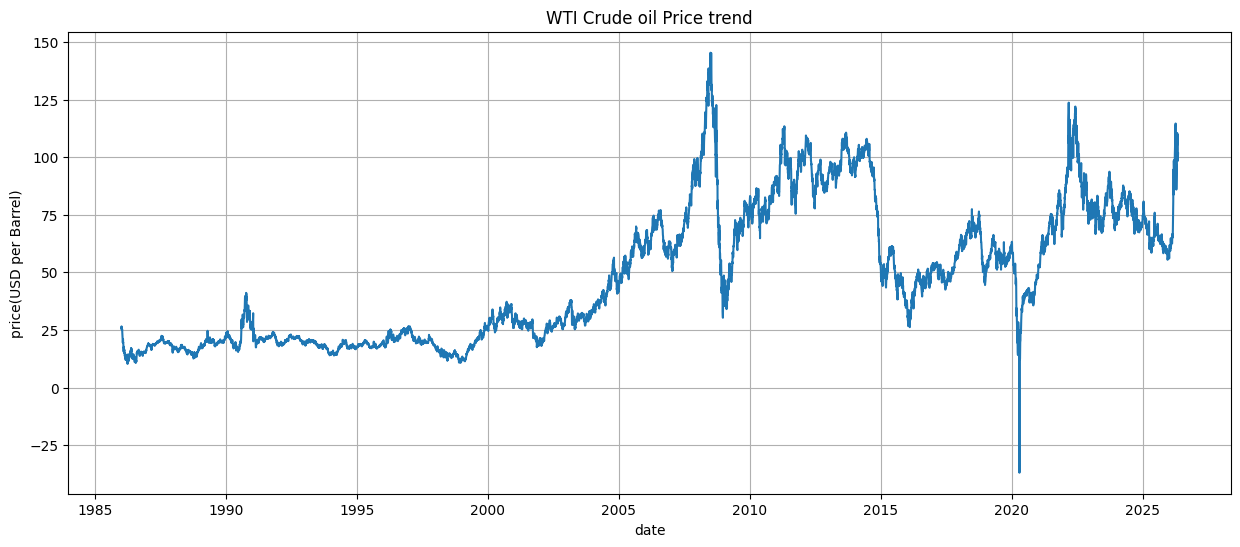

In [15]:
plt.figure(figsize=(15,6))

plt.plot(df['date'],df['price'])

plt.title('WTI Crude oil Price trend')

plt.xlabel('date')

plt.ylabel('price(USD per Barrel)')

plt.grid(True)

plt.show()

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10158 entries, 0 to 10157
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          10158 non-null  datetime64[ns]
 1   price         10158 non-null  float64       
 2   Year          10158 non-null  int32         
 3   Month         10158 non-null  int32         
 4   Quarter       10158 non-null  int32         
 5   Price Change  10157 non-null  float64       
 6   Pct_Change    10157 non-null  float64       
 7   MA_30         10129 non-null  float64       
dtypes: datetime64[ns](1), float64(4), int32(3)
memory usage: 516.0 KB


# **EDA - EXPLORATORY DATA ANALYSIS**

In [17]:
# highest crude price ever

print("highest price: ", df['price'].max())

highest price:  145.31


In [18]:
df.loc[df['price'].idxmax()]

,5678
date,2008-07-03 00:00:00
price,145.31
Year,2008
Month,7
Quarter,3
Price Change,1.57
Pct_Change,1.09225
MA_30,133.902333


In [19]:
# Lowest Crude Oil price

print('lowest price: ', df['price'].min())

lowest price:  -36.98


In [20]:
df.loc[df['price'].idxmin()]

,8643
date,2020-04-20 00:00:00
price,-36.98
Year,2020
Month,4
Quarter,2
Price Change,-55.29
Pct_Change,-301.966139
MA_30,21.658667


In [21]:
# average Crude Oil price

print('average prie: ', round(df['price'].mean(),2))

average prie:  48.34


In [22]:
# average crude oil price by year

yearly_price = df.groupby('Year')['price'].mean()

yearly_price

,price
Year,
1986,15.047689
1987,19.200512
1988,15.965409
1989,19.635486
1990,24.526576
1991,21.541367
1992,20.575564
1993,18.432200
1994,17.196429


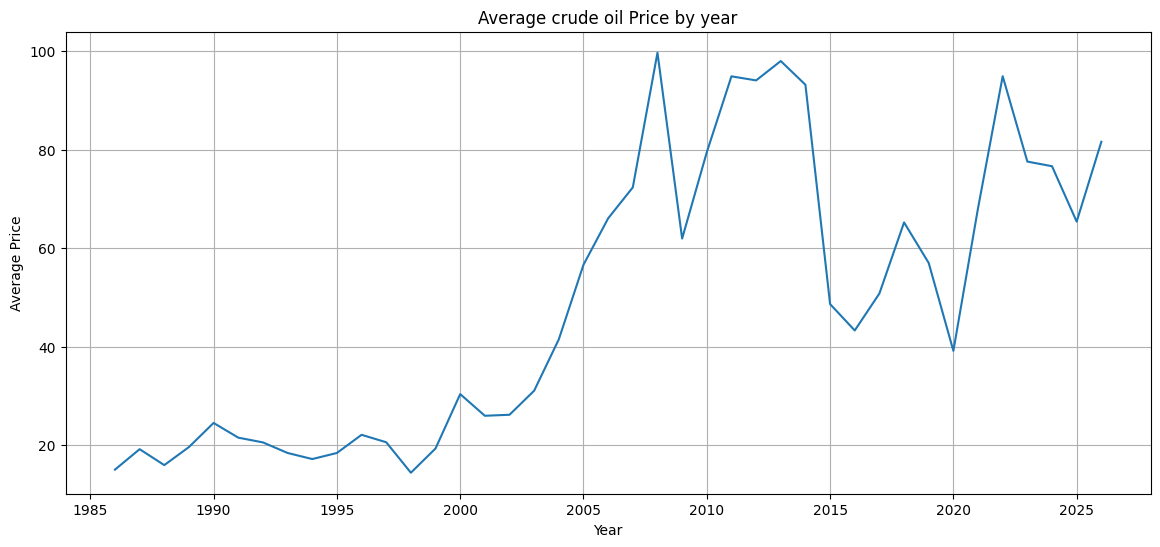

In [23]:
plt.figure(figsize=(14,6))

yearly_price.plot()

plt.title("Average crude oil Price by year")

plt.ylabel("Average Price")

plt.grid(True)

plt.show()

In [24]:
# which year had highest avg price

yearly_price.idxmax()

np.int32(2008)

In [25]:
yearly_price.max()

99.67150197628459

In [26]:
# monthly trend analysisi

df["month_name"] = df['date'].dt.month_name()

In [27]:
monthly_avg = df.groupby('month_name')['price'].mean()

In [28]:
monthly_avg

,price
month_name,
April,49.577983
August,49.535186
December,45.828258
February,46.556785
January,46.065268
July,49.859137
June,49.347477
March,48.428816
May,49.384947


In [29]:
month_order = ['January', 'February','March','April','May','June','July','August','September','October','November','December']

In [30]:
monthly_avg = monthly_avg.reindex(month_order)

In [31]:
monthly_avg

,price
month_name,
January,46.065268
February,46.556785
March,48.428816
April,49.577983
May,49.384947
June,49.347477
July,49.859137
August,49.535186
September,48.950547


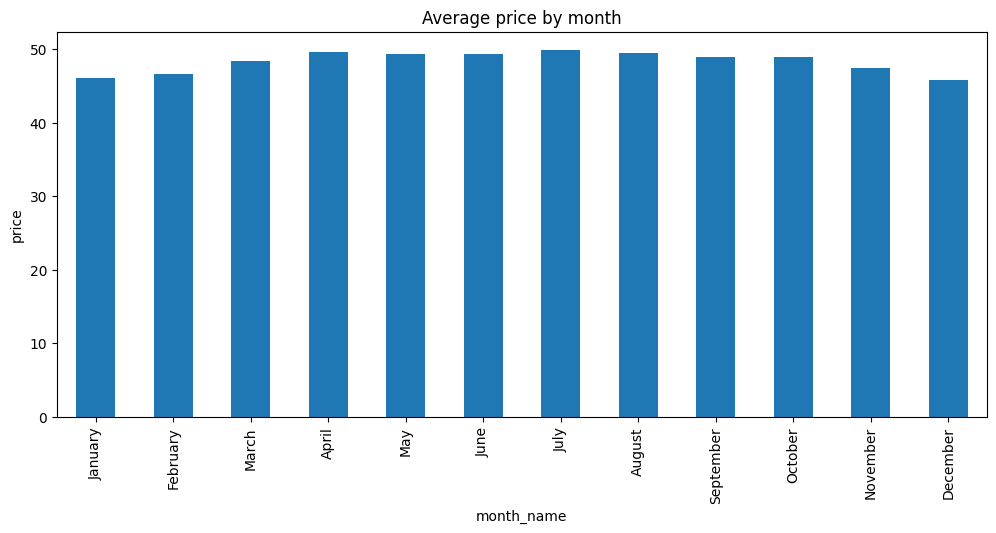

In [32]:
monthly_avg.plot(kind='bar', figsize=(12,5))

plt.title('Average price by month')

plt.ylabel('price')

plt.show()

# **Important Analysis**

In [33]:
# yearly volatility

yearly_volatitlity = df.groupby('Year')['price'].std()

yearly_volatitlity.sort_values(ascending=False).head(10)

,price
Year,
2008,28.619291
2026,18.689393
2014,13.545655
2009,13.387994
2007,12.878812
2022,12.496517
2020,11.559740
2021,8.295409
2011,8.078751


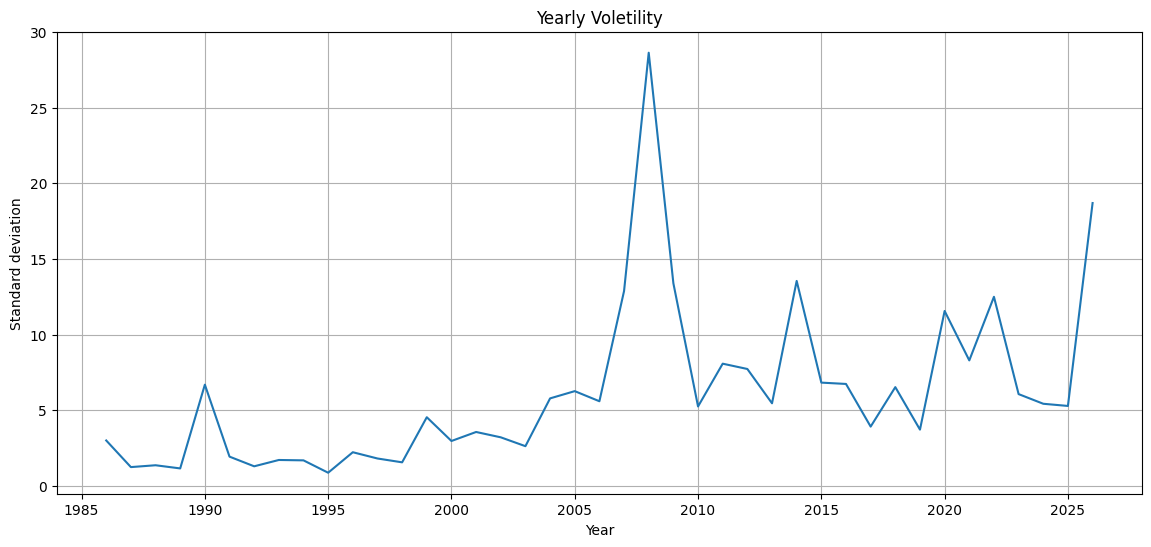

In [34]:
plt.figure(figsize=(14,6))

yearly_volatitlity.plot()

plt.title("Yearly Voletility")

plt.ylabel("Standard deviation")

plt.grid(True)

plt.show()

In [35]:
# years with cheapest avg price

yearly_price.sort_values().head(10)

,price
Year,
1998,14.422072
1986,15.047689
1988,15.965409
1994,17.196429
1995,18.428805
1993,18.432200
1987,19.200512
1999,19.344980
1989,19.635486


In [36]:
# years with highest avg price

yearly_price.sort_values(ascending=False).head(10)

,price
Year,
2008,99.671502
2013,97.982540
2022,94.902869
2011,94.880873
2012,94.053333
2014,93.172222
2026,81.593820
2010,79.475714
2023,77.576532


In [39]:
df.to_csv("refined_crude_oil.csv",index=False)

In [40]:
from google.colab import files
files.download('refined_crude_oil.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>